trying to find a pattern per age window
for each roi/component/network:
    try linear model, quadratic model: gmv_in_roi = b1(bitrh_year)+b2(sex)+b3(tiv)
    collect significance
    compare and pick the best of them 

map which rois are linear/quad/not significant

In [2]:
import statsmodels.formula.api as smf
import pandas as pd          
import matplotlib.pyplot as plt 
import numpy as np

In [3]:
# load data
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/combined_gm_volumes.pkl')
combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')
combined_df = combined_df[(combined_df['classification_label'] == 1) | (combined_df['source'] == 'snbb')]

In [4]:
# define parameters
age_windows = [(20, 24), (25, 29), (30, 34), (35, 39), (40, 44), (45, 49), (50, 54), (55, 59), (60, 64), (65,100)]
# age_windows = [(30, 34), (35, 39)]
# # amygdala:
# roi_list = [421, 422, 448, 449] 

# # somatomotor
# roi_list = [32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270]

# roi_list = list(range(1, 454))



aggregated_rois = pd.read_csv("/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/aggregated_rois.csv")


### analysis of a specific component based on roi_list
calculate linear and quad, pick the best, plot and collect the results 

In [ ]:
from sklearn.preprocessing import StandardScaler

# Aggregate ROIs, normalize volumes, and fit models per age window

results_per_window = []

for min_age, max_age in age_windows:
    # Filter data for this age window
    mask = (combined_df['age_in_years'] >= min_age) & (combined_df['age_in_years'] <= max_age)
    window_df = combined_df[mask].copy()
    
    # Filter to only include ROIs in roi_list
    window_df = window_df[window_df['region_label'].isin(roi_list)]
    
    if len(window_df) < 20:
        continue
    
    # Normalize volumes per ROI (z-score normalization)
    scaler = StandardScaler()
    window_df['volume_normalized'] = window_df.groupby('region_label')['volume_mm3'].transform(
        lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
    )
    
    # Fit both models on aggregated data
    m_lin_agg = smf.ols('volume_normalized ~ birth_year + C(sex) + tiv + age_in_years', 
                         data=window_df).fit()
    m_quad_agg = smf.ols('volume_normalized ~ birth_year + I(birth_year**2) + C(sex) + tiv + age_in_years', 
                          data=window_df).fit()
    
    # Model selection
    is_quad_agg = m_quad_agg.aic < m_lin_agg.aic
    best_model_agg = m_quad_agg if is_quad_agg else m_lin_agg
    model_label_agg = "Quadratic" if is_quad_agg else "Linear"
    
    # Extract vertex if quadratic
    vertex_x_agg = np.nan
    if is_quad_agg:
        quad_coeff = best_model_agg.params.get('I(birth_year ** 2)', np.nan)
        lin_coeff = best_model_agg.params.get('birth_year', np.nan)
        if not np.isnan(quad_coeff) and not np.isnan(lin_coeff) and quad_coeff != 0:
            vertex_x_agg = -lin_coeff / (2 * quad_coeff)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    by_min, by_max = window_df['birth_year'].agg(['min', 'max'])
    by_range = np.linspace(by_min, by_max, 100)
    
    predict_df_agg = pd.DataFrame({
        'birth_year': by_range,
        'sex': window_df['sex'].mode()[0],
        'tiv': window_df['tiv'].mean(),
        'age_in_years': window_df['age_in_years'].mean()
    })
    
    preds_agg = best_model_agg.get_prediction(predict_df_agg).summary_frame()
    
    ax.scatter(window_df['birth_year'], window_df['volume_normalized'], alpha=0.3, c='gray', s=10)
    ax.plot(by_range, preds_agg['mean'], color='crimson', lw=2, label=f'Best Fit ({model_label_agg})')
    ax.fill_between(by_range, preds_agg['mean_ci_lower'], preds_agg['mean_ci_upper'], 
                     color='crimson', alpha=0.15)
    
    ax.set(title=f"Aggregated ROIs ({min_age}-{max_age}y)", xlabel="Birth Year", ylabel="Normalized Volume")
    ax.legend()
    plt.show()
    
    results_per_window.append({
        'age_window': f"{min_age}-{max_age}",
        'model_type': model_label_agg,
        'birth_year_coeff': best_model_agg.params.get('birth_year'),
        'birth_year_pval': best_model_agg.pvalues.get('birth_year'),
        'vertex_x': vertex_x_agg,
        'aic_lin': m_lin_agg.aic,
        'aic_quad': m_quad_agg.aic,
        'n_samples': len(window_df)
    })

# Create summary dataframe
window_summary_df = pd.DataFrame(results_per_window)
print(window_summary_df)

### the same analysis but for all components 


In [ ]:

from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import ast

# --- 1. INITIALIZE GLOBAL RESULTS LIST OUTSIDE THE LOOPS ---
all_component_results = []

for _, row in aggregated_rois.iterrows():
    component_name = row['network_component']
    roi_list = row['roi_list']
    
    # Robust string-to-list conversion
    if isinstance(roi_list, str):
        try:
            roi_list = ast.literal_eval(roi_list)
        except (ValueError, SyntaxError):
            print(f"Error parsing ROI list for {component_name}")
            continue
    
    print(f"Processing Component: {component_name}")

    # --- 2. Iterate over Age Windows ---
    for min_age, max_age in age_windows:
        mask = (
            (combined_df['age_in_years'] >= min_age) & 
            (combined_df['age_in_years'] <= max_age) &
            (combined_df['region_label'].isin(roi_list))
        )
        window_df = combined_df[mask].copy()
        
        if len(window_df) < MIN_SAMPLES:
            continue
        
        # Z-score normalization per ROI
        scaler = StandardScaler()
        window_df['volume_normalized'] = window_df.groupby('region_label')['volume_mm3'].transform(
            lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
        )
        
        # Fit Models
        m_lin_agg = smf.ols('volume_normalized ~ birth_year + C(sex) + tiv + age_in_years', data=window_df).fit()
        m_quad_agg = smf.ols('volume_normalized ~ birth_year + I(birth_year**2) + C(sex) + tiv + age_in_years', data=window_df).fit()
        
        # Selection & Vertex
        is_quad_agg = m_quad_agg.aic < m_lin_agg.aic
        best_model_agg = m_quad_agg if is_quad_agg else m_lin_agg
        model_label_agg = "Quadratic" if is_quad_agg else "Linear"
        
        vertex_x_agg = np.nan
        if is_quad_agg:
            quad_coeff = best_model_agg.params.get('I(birth_year ** 2)', np.nan)
            lin_coeff = best_model_agg.params.get('birth_year', np.nan)
            if not np.isnan(quad_coeff) and quad_coeff != 0:
                vertex_x_agg = -lin_coeff / (2 * quad_coeff)
        
        # --- 3. APPEND TO THE GLOBAL LIST ---
        all_component_results.append({
            'network_component': component_name,
            'age_window': f"{min_age}-{max_age}",
            'model_type': model_label_agg,
            'birth_year_coeff': best_model_agg.params.get('birth_year'),
            'birth_year_pval': best_model_agg.pvalues.get('birth_year'),
            'vertex_x': vertex_x_agg,
            'aic_lin': m_lin_agg.aic,
            'aic_quad': m_quad_agg.aic,
            'n_samples': len(window_df)
        })
        
        # --- Plotting (Optional: Wrap in 'if' if there are too many plots) ---
        fig, ax = plt.subplots(figsize=(10, 6))
        by_min, by_max = window_df['birth_year'].agg(['min', 'max'])
        by_range = np.linspace(by_min, by_max, 100)
        
        predict_df_agg = pd.DataFrame({
            'birth_year': by_range,
            'sex': window_df['sex'].mode()[0],
            'tiv': window_df['tiv'].mean(),
            'age_in_years': window_df['age_in_years'].mean()
        })
        
        preds_agg = best_model_agg.get_prediction(predict_df_agg).summary_frame()
        ax.scatter(window_df['birth_year'], window_df['volume_normalized'], alpha=0.3, c='gray', s=10)
        ax.plot(by_range, preds_agg['mean'], color='crimson', lw=2, label=f'Best Fit ({model_label_agg})')
        ax.fill_between(by_range, preds_agg['mean_ci_lower'], preds_agg['mean_ci_upper'], color='crimson', alpha=0.15)
        ax.set(title=f"{component_name}\nAge Window: {min_age}-{max_age}y", xlabel="Birth Year", ylabel="Normalized Volume")
        ax.legend()
        plt.show()
        plt.close(fig) # Memory management

# --- 4. CREATE THE FINAL SUMMARY DATAFRAME ---
final_summary_df = pd.DataFrame(all_component_results)
print(f"Total rows in summary: {len(final_summary_df)}")

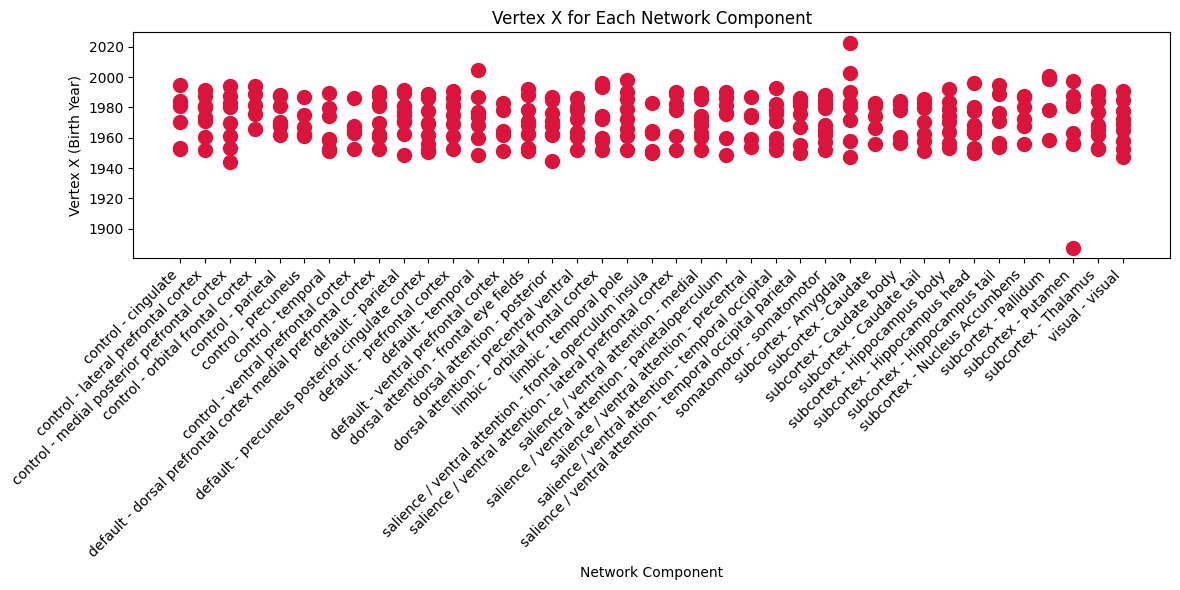

In [ ]:
# the goal was to see if there's a component in which the maximum is in a specific year/generation. the ranges of the vertex are too big to show an effect. 

# for each network_component, plot the vertex
vertex_df = final_summary_df[final_summary_df['vertex_x'].notna()].copy()
vertex_df['vertex_x'] = vertex_df['vertex_x'].astype(float)


plt.figure(figsize=(12, 6))
plt.scatter(vertex_df['network_component'], vertex_df['vertex_x'], c='crimson', s=100)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Network Component")
plt.ylabel("Vertex X (Birth Year)")
plt.title("Vertex X for Each Network Component")
plt.tight_layout()
plt.show()

### model using gam per component

In [ ]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from pygam import LinearGAM, s, f, l
from statsmodels.stats.multitest import multipletests

# --- 1. PREPARE DATA TYPES ---
combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')
combined_df['birth_year'] = pd.to_numeric(combined_df['birth_year'], errors='coerce')
combined_df['tiv'] = pd.to_numeric(combined_df['tiv'].astype(float), errors='coerce')
combined_df['sex'] = combined_df['sex'].astype('category')
combined_df['sex_code'] = combined_df['sex'].cat.codes 

all_component_results = []

# --- 2. LOOP THROUGH COMPONENTS ---
for _, row in aggregated_rois.iterrows():
    component_name = row['network_component']
    roi_list = row['roi_list']
    
    if isinstance(roi_list, str):
        roi_list = ast.literal_eval(roi_list)
    
    print(f"Processing Component: {component_name}")
    
    # Storage for plotting all windows of this component together
    curves_to_plot = []

    for min_age, max_age in age_windows:
        mask = (
            (combined_df['age_in_years'] >= min_age) & 
            (combined_df['age_in_years'] <= max_age) &
            (combined_df['region_label'].isin(roi_list))
        )
        window_df = combined_df[mask].copy()
        
        if len(window_df) < MIN_SAMPLES:
            continue
        
        # Z-score normalization per ROI
        scaler = StandardScaler()
        window_df['volume_normalized'] = window_df.groupby('region_label')['volume_mm3'].transform(
            lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
        )
        
        X = window_df[['birth_year', 'sex_code', 'tiv', 'age_in_years']].values.astype(float)
        y = window_df['volume_normalized'].values.astype(float)

        # --- 3. FIT GAM ---
        gam = LinearGAM(s(0) + f(1) + l(2) + l(3)).fit(X, y)

        # --- 4. PREDICT FOR PLOTTING ---
        by_min, by_max = window_df['birth_year'].agg(['min', 'max'])
        by_range = np.linspace(by_min, by_max, 200)
        
        X_pred = np.zeros((len(by_range), 4))
        X_pred[:, 0] = by_range
        X_pred[:, 1] = window_df['sex_code'].mode()[0]
        X_pred[:, 2] = window_df['tiv'].mean()
        X_pred[:, 3] = window_df['age_in_years'].mean()
        
        y_pred = gam.predict(X_pred)
        
        # Find global extreme for results table
        y_mean = np.mean(y_pred)
        idx_max, idx_min = np.argmax(y_pred), np.argmin(y_pred)
        if abs(y_pred[idx_max] - y_mean) >= abs(y_pred[idx_min] - y_mean):
            vertex_x, extreme_type = by_range[idx_max], 'Maximum'
        else:
            vertex_x, extreme_type = by_range[idx_min], 'Minimum'

        # Store prediction data for the big plot
        curves_to_plot.append({
            'label': f'{min_age}-{max_age}y',
            'x': by_range,
            'y': y_pred,
            'vertex_x': vertex_x
        })

        all_component_results.append({
            'network_component': component_name,
            'age_window': f"{min_age}-{max_age}",
            'birth_year_pval': gam.statistics_['p_values'][0],
            'vertex_x': vertex_x,
            'extreme_type': extreme_type,
            'n_samples': len(window_df)
        })

    # --- 5. COMPONENT-LEVEL PLOT (All Age Windows) ---
    if curves_to_plot:
        plt.figure(figsize=(12, 8))
        # Using a color map to distinguish age windows
        colors = sns.color_palette("viridis", len(curves_to_plot))
        
        for i, curve in enumerate(curves_to_plot):
            plt.plot(curve['x'], curve['y'], label=curve['label'], color=colors[i], lw=2.5)
            # Optional: Mark the vertex for each window with a small dot
            plt.scatter(curve['vertex_x'], curve['y'][np.abs(curve['x'] - curve['vertex_x']).argmin()], 
                        color=colors[i], s=50, edgecolors='black', zorder=5)

        plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
        plt.title(f"Birth Year Effects Across Age Windows: {component_name}", fontsize=16)
        plt.xlabel("Birth Year", fontsize=14)
        plt.ylabel("Partial Effect (Normalized Volume)", fontsize=14)
        plt.legend(title="Age Window", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

# --- 6. MULTIPLE COMPARISON CORRECTION ---
final_summary_df = pd.DataFrame(all_component_results)
if not final_summary_df.empty:
    _, p_fdr, _, _ = multip

### quadratic model per component
to find an important birth year

In [ ]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

# --- 1. PREPARE DATA TYPES ---
combined_df['age_in_years'] = pd.to_numeric(combined_df['age_in_years'], errors='coerce')
combined_df['birth_year'] = pd.to_numeric(combined_df['birth_year'], errors='coerce')
combined_df['tiv'] = pd.to_numeric(combined_df['tiv'], errors='coerce')
combined_df['sex'] = combined_df['sex'].astype('category')

all_component_results = []

# --- 2. LOOP THROUGH COMPONENTS ---
for _, row in aggregated_rois.iterrows():
    component_name = row['network_component']
    roi_list = row['roi_list']
    
    if isinstance(roi_list, str):
        roi_list = ast.literal_eval(roi_list)
    
    print(f"Processing Component: {component_name}")
    curves_to_plot = []

    for min_age, max_age in age_windows:
        mask = (
            (combined_df['age_in_years'] >= min_age) & 
            (combined_df['age_in_years'] <= max_age) &
            (combined_df['region_label'].isin(roi_list))
        )
        window_df = combined_df[mask].copy()
        
        if len(window_df) < MIN_SAMPLES:
            continue
        
        # Z-score normalization per ROI
        scaler = StandardScaler()
        window_df['volume_normalized'] = window_df.groupby('region_label')['volume_mm3'].transform(
            lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).flatten()
        )
        
        # --- 3. FIT QUADRATIC MODEL ---
        # Formula includes birth_year and birth_year squared
        formula = 'volume_normalized ~ birth_year + I(birth_year**2) + sex + tiv + age_in_years'
        model = smf.ols(formula, data=window_df).fit()

        # --- 4. PREDICT & FIND VERTEX ---
        by_min, by_max = window_df['birth_year'].agg(['min', 'max'])
        by_range = np.linspace(by_min, by_max, 200)
        
        predict_df = pd.DataFrame({
            'birth_year': by_range,
            'sex': window_df['sex'].mode()[0],
            'tiv': window_df['tiv'].mean(),
            'age_in_years': window_df['age_in_years'].mean()
        })
        
        y_pred = model.predict(predict_df)
        
        # Analytical Vertex: x = -b / 2a
        b = model.params['birth_year']
        a = model.params['I(birth_year ** 2)']
        
        analytical_vertex = -b / (2 * a) if a != 0 else np.nan
        
        # Determine Global Extreme within the visible range
        # If the analytical vertex is outside the birth years we have, 
        # the extreme is just the min or max of the curve.
        idx_max = np.argmax(y_pred.values)
        idx_min = np.argmin(y_pred.values)
        
        y_mean = np.mean(y_pred)
        if abs(y_pred[idx_max] - y_mean) >= abs(y_pred[idx_min] - y_mean):
            vertex_x, extreme_type = by_range[idx_max], 'Maximum'
        else:
            vertex_x, extreme_type = by_range[idx_min], 'Minimum'

        # Store for plotting
        curves_to_plot.append({
            'label': f'{min_age}-{max_age}y',
            'x': by_range,
            'y': y_pred,
            'vertex_x': vertex_x
        })

        # Calculate a combined p-value for birth year (F-test for both terms)
        # Or simply use the p-value of the quadratic term to see if curvature is significant
        p_val_quad = model.pvalues['I(birth_year ** 2)']

        all_component_results.append({
            'network_component': component_name,
            'age_window': f"{min_age}-{max_age}",
            'quad_p_val': p_val_quad,
            'vertex_x': vertex_x,
            'extreme_type': extreme_type,
            'n_samples': len(window_df),
            'coeff_lin': b,
            'coeff_quad': a
        })

    # --- 5. COMPONENT-LEVEL PLOT ---
    if curves_to_plot:
        plt.figure(figsize=(12, 8))
        colors = sns.color_palette("rocket", len(curves_to_plot)) # Different palette for OLS
        
        for i, curve in enumerate(curves_to_plot):
            plt.plot(curve['x'], curve['y'], label=curve['label'], color=colors[i], lw=2)
            plt.scatter(curve['vertex_x'], curve['y'].iloc[np.abs(curve['x'] - curve['vertex_x']).argmin()], 
                        color=colors[i], s=40, edgecolors='black', zorder=5)

        plt.axhline(0, color='black', lw=1, linestyle='--', alpha=0.3)
        plt.title(f"Quadratic Birth Year Effects: {component_name}", fontsize=16)
        plt.xlabel("Birth Year", fontsize=14)
        plt.ylabel("Predicted Normalized Volume", fontsize=14)
        plt.legend(title="Age Window", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.15)
        plt.tight_layout()
        plt.show()

# --- 6. MULTIPLE COMPARISON CORRECTION ---
final_summary_df = pd.DataFrame(all_component_results)
if not final_summary_df.empty:
    _, p_fdr, _, _ = multipletests(final_summary_df['quad_p_val'], method='fdr_bh')
    final_summary_df['p_val_fdr'] = p_fdr
    final_summary_df['is_significant'] = final_summary_df['p_val_fdr'] < 0.05